# Análisis de comportamiento de clientes y ventas
**csv: Brazilian E-Commerce Public Dataset by Olist**


# Contexto

Este proyecto consiste en un análisis exploratorio de datos de ventas con el objetivo de identificar patrones de comportamiento, regiones con mayor rendimiento, categorías más rentables y clientes más valiosos para el negocio.

A través del análisis de datos se busca obtener información relevante que permita apoyar la toma de decisiones estratégicas relacionadas con ventas, distribución de productos y fidelización de clientes.

# Objetivo del análisis:
- Analizar el comportamiento de ventas y clientes para identificar patrones que ayuden a la toma de decisiones.

# Preguntas de negocio

- ¿Qué regiones generan mayores ingresos?

- ¿Qué regiones presentan menores ventas?
- ¿Qué categorías generan más ingresos?
- ¿Qué categorías tienen mayor volumen de ventas?
- ¿Quiénes son los clientes más valiosos?
- ¿Existen clientes con baja participación en las ventas?
- ¿Cómo evolucionan las ventas a lo largo del tiempo?
- ¿Existen periodos de crecimiento o caída significativa?
- ¿Qué oportunidades de mejora se pueden identificar a partir de los datos?

# Carga de datos de las tablas que utilizaremos

Se realiza un join entre las tablas de productos y ventas para obtener información descriptiva de los productos vendidos.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
orders = pd.read_csv("../data/flow_Qwiklab1/olist_orders_dataset.csv")
items = pd.read_csv("../data/flow_Qwiklab1/olist_order_items_dataset.csv")
customers = pd.read_csv("../data/flow_Qwiklab1/olist_customers_dataset.csv")
products = pd.read_csv("../data/flow_Qwiklab1/olist_products_dataset.csv")

In [4]:
df = items.merge(products, on = "product_id")
df = df.merge(orders, on = "order_id")
df = df.merge(customers, on = "customer_id")
df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,...,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00,871766c5855e863f6eccc05f988b23cb,28013,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,...,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00,eb28e67c4c0b83846050ddfb8a35d051,15775,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,...,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00,3818d81c6709e39d06b2738a8d3a2474,35661,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,...,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00,af861d436cfc08b2c2ddefd0ba074622,12952,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,...,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00,64b576fb70d441e8f1b2d7d446e483c5,13226,varzea paulista,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,utilidades_domesticas,43.0,1002.0,...,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18 00:00:00,0c9aeda10a71f369396d0c04dce13a64,65077,sao luis,MA
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,informatica_acessorios,31.0,232.0,...,delivered,2018-07-14 10:26:46,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-07-23 20:31:55,2018-08-01 00:00:00,0da9fe112eae0c74d3ba1fe16de0988b,81690,curitiba,PR
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,esporte_lazer,43.0,869.0,...,delivered,2017-10-23 17:07:56,2017-10-24 17:14:25,2017-10-26 15:13:14,2017-10-28 12:22:22,2017-11-10 00:00:00,cd79b407828f02fdbba457111c38e4c4,4039,sao paulo,SP
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,informatica_acessorios,56.0,1306.0,...,delivered,2017-08-14 23:02:59,2017-08-15 00:04:32,2017-08-15 19:02:53,2017-08-16 21:59:40,2017-08-25 00:00:00,eb803377c9315b564bdedad672039306,13289,vinhedo,SP


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  object 
 1   order_item_id                  112650 non-null  int64  
 2   product_id                     112650 non-null  object 
 3   seller_id                      112650 non-null  object 
 4   shipping_limit_date            112650 non-null  object 
 5   price                          112650 non-null  float64
 6   freight_value                  112650 non-null  float64
 7   product_category_name          111047 non-null  object 
 8   product_name_lenght            111047 non-null  float64
 9   product_description_lenght     111047 non-null  float64
 10  product_photos_qty             111047 non-null  float64
 11  product_weight_g               112632 non-null  float64
 12  product_length_cm             

Se realizó una exploración inicial del dataset utilizando df.info(), identificando la presencia de valores nulos en algunas columnas relacionadas con el proceso de entrega.
Se observa que las columnas order_delivered_carrier_date y order_delivered_customer_date presentan valores nulos, lo que indica que existen pedidos que no han sido completamente entregados o que se encuentran en proceso.

In [32]:
df.describe()

,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_zip_code_prefix
count,112650.000000,112650.000000,112650.000000,111047.000000,111047.000000,111047.000000,112632.000000,112632.000000,112632.000000,112632.000000,112650.000000
mean,1.197834,120.653739,19.990320,48.775978,787.867029,2.209713,2093.672047,30.153669,16.593766,22.996546,35119.309090
std,0.705124,183.633928,15.806405,10.025581,652.135608,1.721438,3751.596884,16.153449,13.443483,11.707268,29866.120801
min,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1003.000000
25%,1.000000,39.900000,13.080000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,11310.000000
50%,1.000000,74.990000,16.260000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000,24340.000000
75%,1.000000,134.900000,21.150000,57.000000,987.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,59028.750000
max,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99990.000000


# Ventas Totales


In [7]:
total_ventas = df["price"].sum()
print(f"Ventas totales: {total_ventas:,.0f}")

Ventas totales: 13,591,644


El total de ventas asciende a 13,591,644, lo que evidencia un volumen significativo de transacciones. Este valor permite establecer una referencia para analizar la distribución de ingresos, identificar segmentos clave y detectar oportunidades de optimización en el negocio.

# Ventas por región

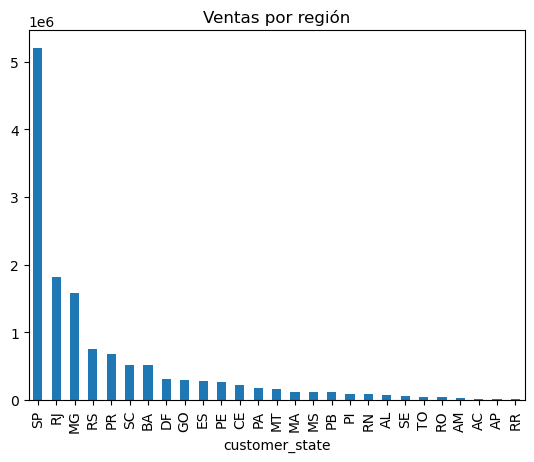

In [11]:
ventas_region = df.groupby("customer_state")["price"].sum().sort_values(ascending=False)
ventas_region.plot(kind="bar", title="Ventas por región")
plt.show()

Las ventas muestran una alta concentración en regiones como SP, RJ y MG, lo que sugiere que estos mercados representan los principales focos de ingreso para el negocio. Por otro lado, regiones con menor volumen de ventas podrían representar oportunidades de crecimiento o requerir estrategias específicas para aumentar su participación. Esta distribución refleja una clara desigualdad en la demanda a nivel geográfico.

# Categorías que más venden VS Categorías que más generan dinero

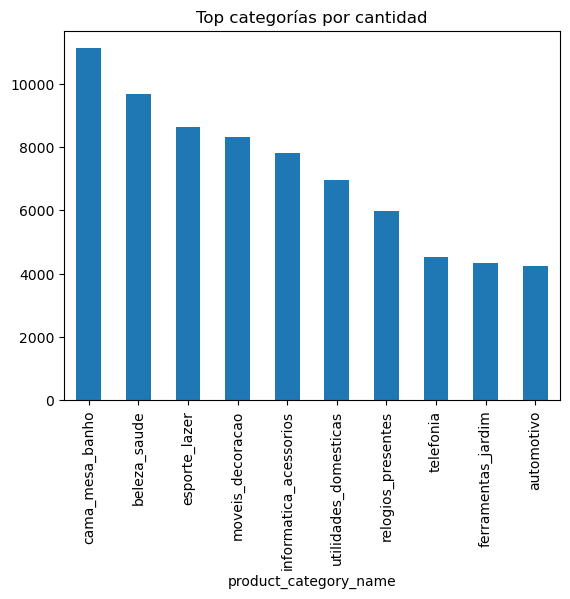

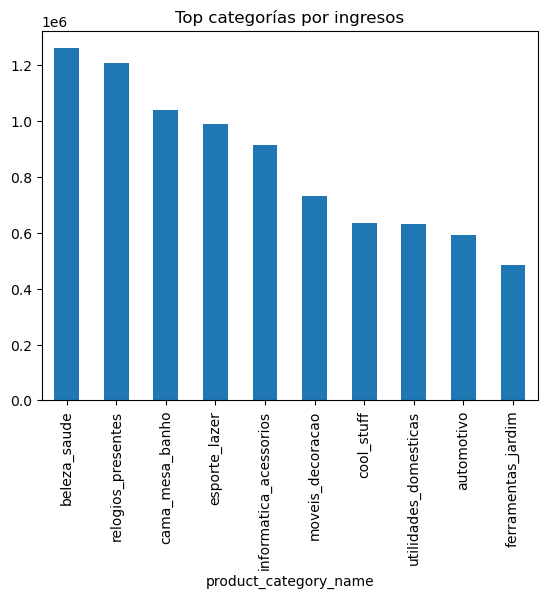

In [12]:
# Cantidad
df.groupby("product_category_name")["order_item_id"].count().sort_values(ascending=False).head(10).plot(kind="bar", title="Top categorías por cantidad")

plt.show()

# Dinero
df.groupby("product_category_name")["price"].sum().sort_values(ascending=False).head(10).plot(kind="bar", title="Top categorías por ingresos")

plt.show()

Algunas categorías presentan alto volumen de ventas, pero no necesariamente generan mayores ingresos, evidenciando diferencias en el valor de los productos.

# Productos más vendidos

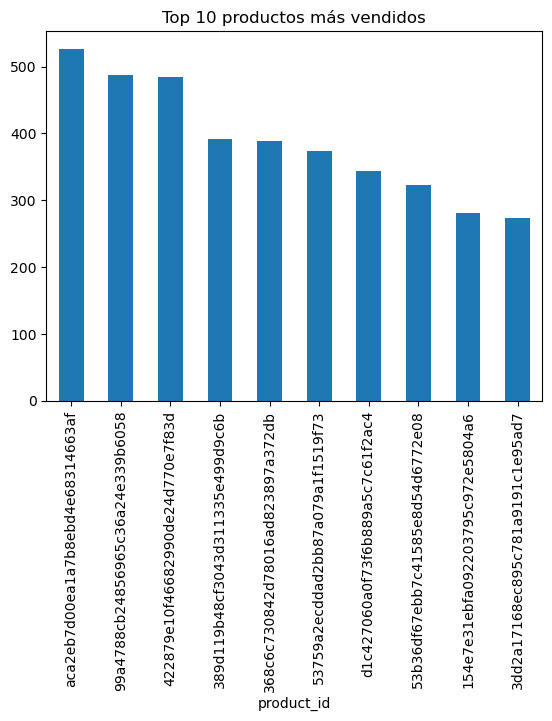

In [13]:
df["product_id"].value_counts().head(10).plot(kind="bar", title="Top 10 productos más vendidos")
plt.show()

Se observa que las ventas se concentran en un conjunto reducido de productos, lo que evidencia un comportamiento de compra no uniforme. Esta concentración permite identificar productos clave para el negocio, los cuales podrían priorizarse en estrategias de stock, promoción y marketing para maximizar ingresos.

# Clientes más valiosos

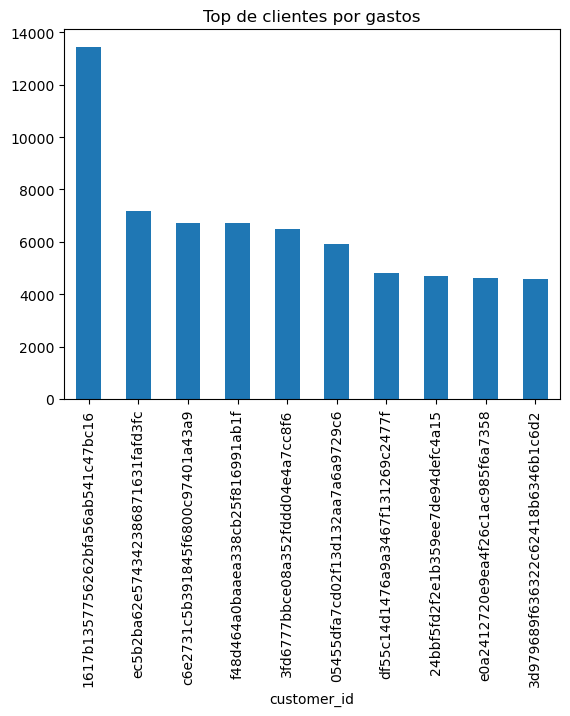

In [15]:
df.groupby("customer_id")["price"].sum().sort_values(ascending=False).head(10).plot(kind="bar", title="Top de clientes por gastos")
plt.show()


Se identifica que un grupo reducido de clientes concentra una proporción importante de los ingresos, lo que evidencia una alta concentración del valor en pocos usuarios. Este hallazgo permite orientar estrategias de negocio hacia la retención y fidelización de estos clientes clave, así como diseñar acciones para aumentar el gasto en clientes de menor participación.

# Ventas en el tiempo

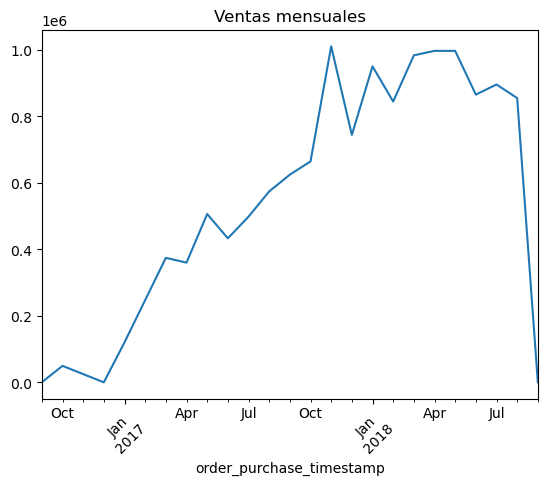

In [16]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

ventas_tiempo = df.groupby(df["order_purchase_timestamp"].dt.to_period("M"))["price"].sum()
ventas_tiempo.plot(title="Ventas mensuales")

plt.xticks(rotation=45)
plt.show()
                                            

El análisis temporal muestra un crecimiento progresivo de las ventas, especialmente durante el año 2017 y comienzos de 2018, seguido de ciertas fluctuaciones. Este comportamiento sugiere una expansión del negocio en el tiempo, con posibles efectos de estacionalidad o campañas comerciales que impactan en determinados meses.

# Pedidos atrasados

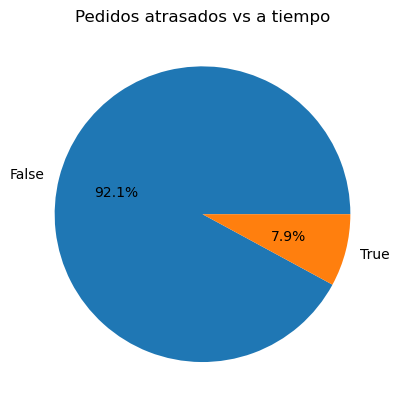

In [19]:
df_time["late"] = df_time["order_delivered_customer_date"] > df_time["order_estimated_delivery_date"]

df_time["late"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Pedidos atrasados vs a tiempo")
plt.ylabel("")
plt.show()

Se observa que aproximadamente un 7.91% de los pedidos presentan retrasos en la entrega. Si bien la mayoría de las entregas se realiza dentro del plazo estimado, existe una proporción relevante de pedidos atrasados, lo que podría indicar oportunidades de mejora en los procesos logísticos.

# Tiempo de entrega

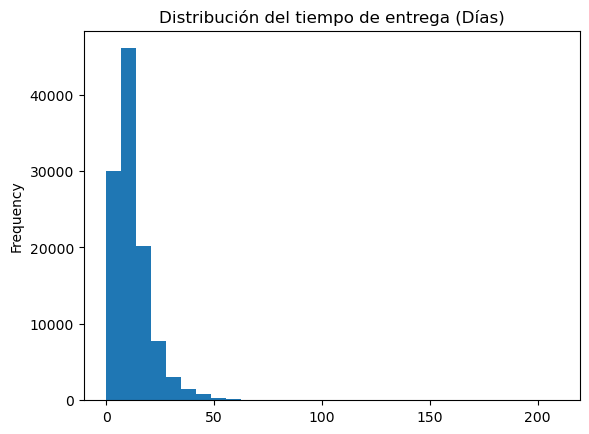

In [25]:
# Convertir a fechas
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"])

# Filtrar datos válidos
df_time = df.dropna(subset=[
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]).copy()
df_time["delivery_time"] = df_time["order_delivered_customer_date"] - df_time["order_purchase_timestamp"]
df_time["delivery_time"].dt.days.plot(kind="hist", bins=30)
plt.title("Distribución del tiempo de entrega (Días)")
plt.show()

La distribución del tiempo de entrega muestra una alta concentración en torno a los 12 días, lo que refleja un desempeño logístico consistente para la mayoría de los pedidos. Sin embargo, la presencia de una cola larga en la distribución indica la existencia de entregas con tiempos considerablemente mayores, lo que podría estar asociado a factores como ubicación geográfica o problemas operativos. Este comportamiento sugiere oportunidades de mejora en la gestión de casos excepcionales.

Este análisis se complementa con el cálculo de pedidos atrasados, donde se observa que aproximadamente un 7.91% de los pedidos no cumple con la fecha estimada de entrega, reforzando la necesidad de optimizar ciertos procesos logísticos.

# Insights

Se recomienda analizar las regiones con menores ingresos para identificar si el bajo rendimiento se debe a la demanda de productos, preferencias de consumo o problemas de envío y logística.

Se recomienda asegurar mayor stock en las categorías que más ingresos generan y que también están dentro de las más vendidas, ya que son las que tienen mayor demanda y aportan más al negocio.

Se observó que una gran parte de los ingresos proviene de un grupo específico de clientes, por lo que se recomienda aplicar estrategias de fidelización para mantenerlos activos y satisfechos. También Se recomienda analizar a los clientes con menores ingresos para determinar si su bajo aporte se relaciona con la región donde se encuentran o con una menor demanda de los productos que consumen.

Las ventas presentan un crecimiento considerable durante 2017, pero muestran una fuerte caída en 2018. Esto podría indicar cambios en la demanda, problemas operacionales o factores externos que deberían ser evaluados.



# Conclusión
A partir del análisis realizado, se identificaron patrones relevantes en el comportamiento de ventas y clientes. Las ventas se concentran en ciertas regiones y categorías específicas, lo que sugiere oportunidades para enfocar estrategias comerciales.

Se observó que algunas categorías tienen alto volumen de ventas pero no necesariamente generan mayores ingresos, lo que evidencia diferencias en el valor de los productos. Además, se identificó que un grupo reducido de clientes concentra gran parte del gasto.

En términos logísticos, el tiempo promedio de entrega es de aproximadamente 12 días, y cerca de un 7.91% de los pedidos presenta retrasos, lo que indica posibles oportunidades de mejora en los procesos de distribución.

En conjunto, estos hallazgos permiten apoyar la toma de decisiones en áreas como marketing, ventas y logística.